<a href="https://colab.research.google.com/github/Ramprashanth17/info6105-Data-Science/blob/main/Teleco_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Customer Churn in Telecommunications

Customer churn represents a critical challenge in the telecommunications industry,
with annual attrition rates exceeding 30% and customer acquisition costs 6-7 times
higher than retention costs. This notebook presents a comprehensive machine learning
approach to predict telecom customer churn, enabling proactive retention strategies.

Using the Telco Customer Churn dataset (7,043 customers, 19 features), we develop
and compare three predictive models: Logistic Regression, Random Forest, and XGBoost.


**Dataset:** IBM Telco Customer Churn (Kaggle)  
**Tools:** Python, scikit-learn, XGBoost, SHAP, pandas, matplotlib, seaborn

# 1. Setup and Imports

I am using Kaggle API to load the dataset.

In [ ]:
!pip install Kaggle


In [ ]:
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [ ]:
!mkdir -p ~/.kaggle
!echo '{"username":"'$KAGGLE_USERNAME'","key":"'$KAGGLE_KEY'"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d yeanzc/telco-customer-churn-ibm-dataset

Dataset URL: https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset
License(s): other
telco-customer-churn-ibm-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip telco-customer-churn-ibm-dataset.zip

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/content/Telco_customer_churn.xlsx')
df.head()

Archive:  telco-customer-churn-ibm-dataset.zip
replace Telco_customer_churn.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Telco_customer_churn.xlsx  


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# Exploratory Data Analysis (EDA) and Data Pre-processing


In [ ]:
df.columns #Columns present in the dataset

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
df.info(verbose=True) #Information of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
print(f"The total no.of null values in the dataset per column is: \n {df.isna().sum()}")

The total no.of null values in the dataset per column is: 
 CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


In [ ]:
print(f"No.of duplicated rows is: \n {df.duplicated().sum()}")

No.of duplicated rows is: 
 0


Total charges is in object dtype which needs to be changed to numerical type

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['TotalCharges'].isna().sum()

np.int64(11)

There are 11 records with null values in Total Charges column. Let's fill them with the product of monthly charges times tenure

In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['Monthly Charges'] * df['Tenure Months'])
df['TotalCharges'].isna().sum()

np.int64(0)

In [ ]:
# Let's see the no.of unique values per column

df.nunique()

# The features with low unique values are considered to be low cardinal, which doesn't offer much info.
# The features with high unique values are considered to be high cardinal, which challenges while modeling

,0
CustomerID,7043
Count,1
Country,1
State,1
City,1129
Zip Code,1652
Lat Long,1652
Latitude,1652
Longitude,1651
Gender,2


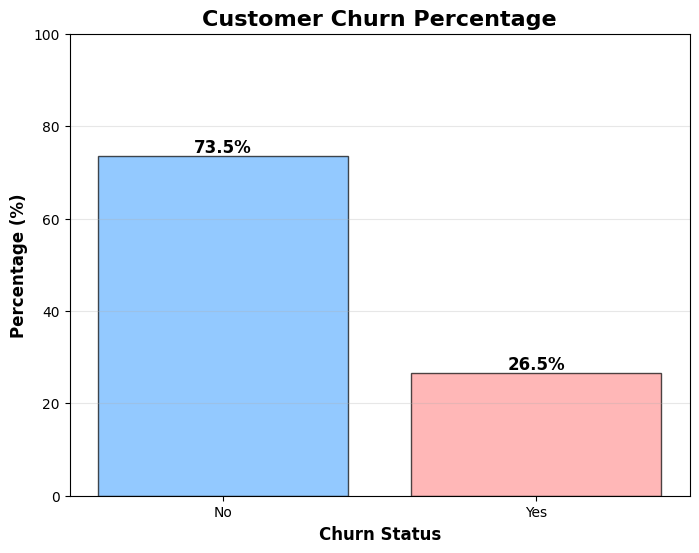

In [ ]:
import matplotlib.pyplot as plt

# Calculate churn percentages
churn_counts = df['Churn Label'].value_counts()
churn_percentage = (churn_counts / churn_counts.sum()) * 100

# Create bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(churn_percentage.index, churn_percentage,
               color=['#66b3ff', '#ff9999'],
               edgecolor='black',
               alpha=0.7)

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Churn Status', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Customer Churn Percentage', fontsize=16, fontweight='bold')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.show()

We can see that 26.5% of the customers have decided to leave. What could be the reasons for that & what actions can we suggest to help address this problem?

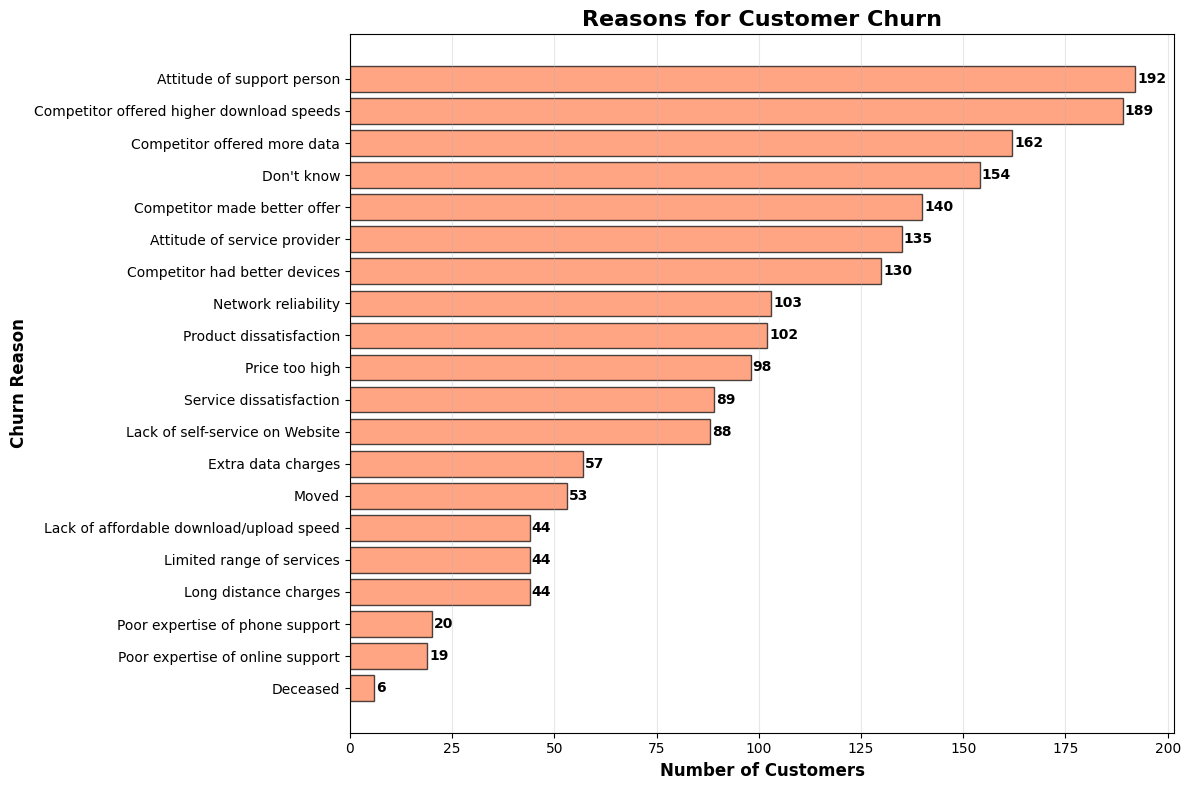

In [ ]:
values = df['Churn Reason'].value_counts(ascending= False).values

keys = df['Churn Reason'].value_counts(ascending= False).keys()

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(keys, values, color='coral', edgecolor='black', alpha=0.7)

# Add count labels at the end of each bar
for i, v in enumerate(values):
    plt.text(v + 0.5, i, str(v), va='center', fontweight='bold')

plt.xlabel('Number of Customers', fontsize=12, fontweight='bold')
plt.ylabel('Churn Reason', fontsize=12, fontweight='bold')
plt.title('Reasons for Customer Churn', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()  # Highest count at the top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

It is found that most of the customers churned due to the attitude of the support person; followed by competitor offering better prices. Mainly the reasons can be categorized into two types: Internal reasons to churn like Lack of support, prices, etc. and External reasons to churn like Competition from other external providers.

In [ ]:
df.groupby(['Country','State'])['CustomerID'].count()

,,CustomerID
Country,State,
United States,California,7043


# Cities with high customer churn


In [ ]:
import plotly.express as px
import pandas as pd

# Calculate stats by city
city_stats = df.groupby('City').agg({
    'Churn Label': [
        ('Total_Customers', 'count'),
        ('Churned_Customers', lambda x: (x == 'Yes').sum()),
        ('Churn_Rate', lambda x: (x == 'Yes').sum() / len(x) * 100)
    ]
})

city_stats.columns = ['Total_Customers', 'Churned_Customers', 'Churn_Rate']
city_stats = city_stats[city_stats['Total_Customers'] >= 20].reset_index()

# Create interactive bubble chart
fig = px.scatter(city_stats,
                 x='Total_Customers',
                 y='Churn_Rate',
                 size='Churned_Customers',  # Bubble size
                 color='Churn_Rate',  # Color by churn rate
                 hover_name='City',  # Shows city name on hover
                 hover_data={
                     'Total_Customers': True,
                     'Churned_Customers': True,
                     'Churn_Rate': ':.2f'  # Format to 2 decimal places
                 },
                 color_continuous_scale='Reds',
                 size_max=60,  # Maximum bubble size
                 title='City Churn Analysis: Rate vs Customer Count (Hover for Details)')

# Update layout
fig.update_layout(
    width=1200,
    height=700,
    xaxis_title='Total Customers',
    yaxis_title='Churn Rate (%)',
    font=dict(size=12),
    hovermode='closest'
)

fig.show()

Cities with highest churn rate with lowest populations are:
* Santa Rosa
* North HollyWood
* Modesta

Cities with highest population but with around 30% churn rate are:
* Los Angeles and San Diego

The lowest churn rate was observed in these two cities:
* Bakersfield and Corona


# Relation between Tenure and Churn


In [ ]:
import plotly.express as px

fig = px.histogram(df,
                   x="Tenure Months",
                   color="Churn Label",
                   color_discrete_map={
                       'Yes': 'red',
                       'No': 'green'
                   })
fig.show()

It has been observed that highest churn is observed during the initial months of churn i.e. <10 months. However, after the 11 months the churn rate is gradually decreasing.

**Churn based on contract**

In [ ]:
fig = px.pie(df.groupby(['Contract','Churn Label'])['CustomerID'].count().reset_index(),
            names='Contract',
            facet_col = 'Churn Label',
            title = 'Churn rate by contract type',
              color_discrete_map={
                       'Yes': 'red',
                       'No': 'green'
                   })

fig.show()

88.6 % of customers left the services had a month-to-month contract. Followed by One year plans and the least is two-year.

In contrast to that, it is observed that 42.9% who isn't churned is month-month; followed by two year and the least was one year plan.

## Demographics of Churn

In [ ]:
# Any gender relation to churn

# Calculate the percentage distribution
Gender_ChurnLabel = df.groupby(['Gender', 'Churn Label']).size().reset_index(name='count')

# Calculate percentage within each Gender group
Gender_ChurnLabel['rate'] = Gender_ChurnLabel.groupby('Gender')['count'].transform(lambda x: (x / x.sum()) * 100)

# Create 100% stacked bar chart
fig = px.bar(Gender_ChurnLabel,
             x='rate',
             y='Gender',
             color='Churn Label',
             title='100% Stacked Bar Chart - Gender by Churn Status',
             text='rate',
             labels={'rate': 'Percentage (%)'},
             orientation='h',  # Horizontal bars
             color_discrete_map={'Yes': '#E74C3C', 'No': '#2ECC71'})

# Format the chart
fig.update_traces(texttemplate='%{text:.1f}%', textposition='inside')
fig.update_layout(
    barmode='stack',
    xaxis_title='Percentage (%)',
    yaxis_title='Gender',
    font=dict(size=12),
    height=400,
    width=800
)

fig.show()

Gender doesn't have much relationship to cause churn.

**Churn by Payment Support**


In [ ]:
Payment_Method_counts= df['Payment Method'].value_counts()
fig = px.pie(names= Payment_Method_counts.keys(), values= Payment_Method_counts.values, title='Payment Method Distribution')
fig.show()

In [ ]:
grouped = df.groupby(['Payment Method', 'Churn Label'])['CustomerID'].count()
total_counts = grouped.groupby('Payment Method').transform('sum')
normalized_count = round(grouped / total_counts,2)
Payment_Method_ChurnLabel = pd.DataFrame({'rate': normalized_count}).reset_index()

fig = px.bar(Payment_Method_ChurnLabel, x='rate', y='Payment Method', color='Churn Label',
             title='100% Stacked Bar Chart by Payment Method and Churn Label', text= 'rate',
             labels={'rate': 'Percentage'}, color_discrete_map={'Yes': '#E74C3C', 'No': '#2ECC71'} )

fig.update_layout(barmode='relative')  # Make the bar chart 100% stacked

fig.show()

Customers who were paying through Electronic check were having the highest churn rate.

In [ ]:
grouped = df.groupby(['Internet Service', 'Churn Label'])['CustomerID'].count()
total_counts = grouped.groupby('Internet Service').transform('sum')
normalized_count = round(grouped / total_counts,2)
Internet_Service_ChurnLabel = pd.DataFrame({'rate': normalized_count}).reset_index()

fig = px.bar(Internet_Service_ChurnLabel, x='rate', y='Internet Service', color='Churn Label',
             title='100% Stacked Bar Chart by Internet Service and Churn Label', text= 'rate',
             labels={'rate': 'Percentage'},color_discrete_map={'Yes': '#E74C3C', 'No': '#2ECC71'})

fig.update_layout(barmode='relative')  # Make the bar chart 100% stacked

fig.show()

# Feature Engineering for the model

In [ ]:
# Let's drop the columns that we won't be using for the model

clean_df = df.drop(['Country','State','Count','Zip Code','Churn Reason','City','Churn Score','Churn Label','CLTV','CustomerID','Lat Long',
                    'Latitude','Longitude', 'Total Charges'], axis = 1)

Dropping country and state as they have only one value, Count, Customer Id, Lat Long doesn't provide enough causal value to improve the model performance. Similarly, churn reason has high cardinality and it's generally known only after a customer is left, hence churn score, churn value and CLTV are to be dropped as they're values already predicted from IBM. Churn Label is the same as churn value, since churn value is present I am removing churn label.



In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [ ]:
clean_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Churn Value,TotalCharges
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,1,108.15
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,1,151.65
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,1,820.50
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,1,3046.05
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,1,5036.30


There are some columns which needs to be encoded or changed from categorical to numerical such as Gender, Senior citizen etc.

In [ ]:
model_df = clean_df.copy()
model_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Churn Value,TotalCharges
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,1,108.15
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,1,151.65
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,1,820.50
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,1,3046.05
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,1,5036.30


# Encoding of columns

There are some columns which contains binary values in categorical values and some other columns with 3-4 values and all these columns are low cardinality, hence, we will encode them using Label Encoding for Binary Values and One-hot encoding for values > 2, this maps the numerical values to respective categorical values which helps us in modeling.

In [ ]:
from sklearn.preprocessing import LabelEncoder

def smart_encode(model_df, target_col='Churn Value'):
    """
    Smart encoding: LabelEncoder for binary, One-Hot for multi-category
    """
    df_encoded = model_df.copy()
    label_encoders = {}

    # 1. Encode target variable
    if target_col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[target_col] = le.fit_transform(df_encoded[target_col])
        label_encoders[target_col] = le
        print(f"Target ({target_col}): {dict(zip(le.classes_, le.transform(le.classes_)))}")

    # 2. Identify categorical columns
    categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()

    binary_cols = []
    multi_category_cols = []

    for col in categorical_cols:
        if df_encoded[col].nunique() <= 2:
            binary_cols.append(col)
        else:
            multi_category_cols.append(col)

    print(f"\nBinary columns: {binary_cols}")
    print(f"Multi-category columns: {multi_category_cols}")

    # 3. LabelEncoder for binary columns
    for col in binary_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le
        print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

    # 4. One-Hot Encoding for multi-category columns
    if multi_category_cols:
        df_encoded = pd.get_dummies(df_encoded, columns=multi_category_cols, drop_first=True)
        print(f"\nOne-hot encoded: {multi_category_cols}")

    return df_encoded, label_encoders

# Use it
df_final, encoders = smart_encode(model_df)

print(f"\nOriginal shape: {model_df.shape}")
print(f"Encoded shape: {df_final.shape}")
print(f"\nColumn dtypes:")
print(df_final.dtypes.value_counts())

Target (Churn Value): {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

Binary columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing']
Multi-category columns: ['Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method']
Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Senior Citizen: {'No': np.int64(0), 'Yes': np.int64(1)}
Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
Phone Service: {'No': np.int64(0), 'Yes': np.int64(1)}
Paperless Billing: {'No': np.int64(0), 'Yes': np.int64(1)}

One-hot encoded: ['Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method']

Original shape: (7043, 20)
Encoded shape: (7043, 31)

Column dtypes:
bool       21
int64     

In [ ]:
df_final.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Churn Value,TotalCharges,...,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,1,0,0,0,2,1,1,53.85,1,108.15,...,False,False,False,False,False,False,False,False,False,True
1,0,0,0,1,2,1,1,70.70,1,151.65,...,False,False,False,False,False,False,False,False,True,False
2,0,0,0,1,8,1,1,99.65,1,820.50,...,False,False,True,False,True,False,False,False,True,False
3,0,0,1,1,28,1,1,104.80,1,3046.05,...,True,False,True,False,True,False,False,False,True,False
4,1,0,0,1,49,1,1,103.70,1,5036.30,...,False,False,True,False,True,False,False,False,False,False


There are some columns which still have boolean values like True or False instead of 0's or 1's, we'll convert them into binary digits.

In [ ]:
# If you already have df_final with boolean columns:

# Check what you have
print("Before conversion:")
print(df_final.dtypes.value_counts())

# Convert all booleans to integers
df_final = df_final.astype({col: int for col in df_final.select_dtypes(include=['bool']).columns})

# Verify
print("\nAfter conversion:")
print(df_final.dtypes.value_counts())

# Look at the data
print("\nSample data:")
print(df_final.head())

Before conversion:
bool       21
int64       8
float64     2
Name: count, dtype: int64

After conversion:
int64      29
float64     2
Name: count, dtype: int64

Sample data:
   Gender  Senior Citizen  Partner  Dependents  Tenure Months  Phone Service  \
0       1               0        0           0              2              1   
1       0               0        0           1              2              1   
2       0               0        0           1              8              1   
3       0               0        1           1             28              1   
4       1               0        0           1             49              1   

   Paperless Billing  Monthly Charges  Churn Value  TotalCharges  ...  \
0                  1            53.85            1        108.15  ...   
1                  1            70.70            1        151.65  ...   
2                  1            99.65            1        820.50  ...   
3                  1           104.80            1   

In [ ]:
df_final.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Paperless Billing', 'Monthly Charges', 'Churn Value',
       'TotalCharges', 'Multiple Lines_No phone service', 'Multiple Lines_Yes',
       'Internet Service_Fiber optic', 'Internet Service_No',
       'Online Security_No internet service', 'Online Security_Yes',
       'Online Backup_No internet service', 'Online Backup_Yes',
       'Device Protection_No internet service', 'Device Protection_Yes',
       'Tech Support_No internet service', 'Tech Support_Yes',
       'Streaming TV_No internet service', 'Streaming TV_Yes',
       'Streaming Movies_No internet service', 'Streaming Movies_Yes',
       'Contract_One year', 'Contract_Two year',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')

# Feature Selection for the model

Let's find out which features are helpful for us in predicting the target column ie. Churn.

I've tried various methods to find out the features which are helpful to us.

Top 15 Features - Comparison Across Methods:
                                  Feature  Correlation  Mutual_Info     F_Score  RF_Importance  Average_Score
4                           Tenure Months     0.352229     0.075842  997.268010       0.161879       0.954502
26                      Contract_Two year     0.302253     0.062739  707.919254       0.029892       0.631673
8                            TotalCharges     0.198324     0.043808  288.278961       0.197058       0.604606
11           Internet Service_Fiber optic     0.308020     0.043988  738.046042       0.037692       0.591703
7                         Monthly Charges     0.193356     0.050515  273.463704       0.169317       0.583507
28        Payment Method_Electronic check     0.301919     0.041496  706.195028       0.038652       0.572303
3                              Dependents     0.248542     0.042601  463.582354       0.036708       0.473744
17  Device Protection_No internet service     0.227890     0.042964  385.69

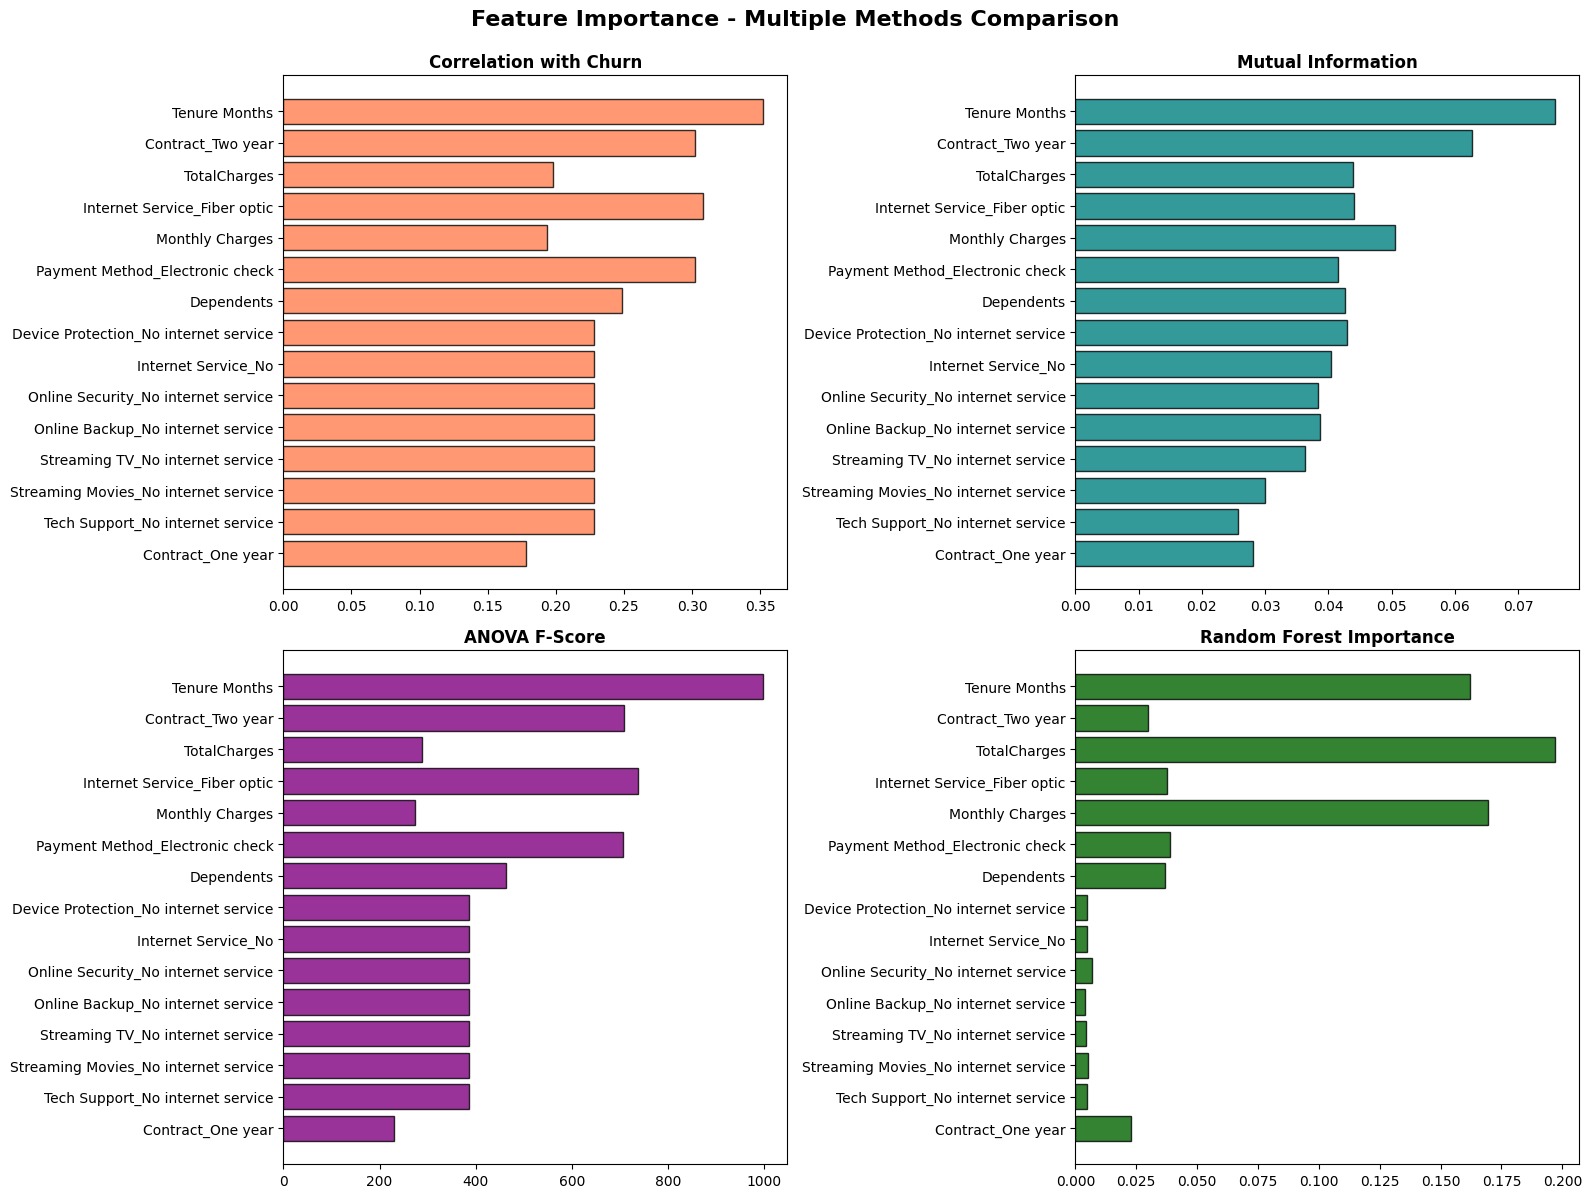

In [ ]:
# Let's check the relationship between the features to the target value

import pandas as pd
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier

# Prepare data
X = df_final.drop('Churn Value', axis=1)
y = df_final['Churn Value']

# Calculate different metrics
correlation = df_final.corr()['Churn Value'].drop('Churn Value').abs()
mi_scores = mutual_info_classif(X, y, random_state=42)
f_scores, _ = f_classif(X, y)

# Train RF for importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
rf_importance = rf.feature_importances_

# Combine into one DataFrame
comparison_df = pd.DataFrame({
    'Feature': X.columns,
    'Correlation': correlation.values,
    'Mutual_Info': mi_scores,
    'F_Score': f_scores,
    'RF_Importance': rf_importance
})

# Normalize to 0-1 for comparison
for col in ['Correlation', 'Mutual_Info', 'F_Score', 'RF_Importance']:
    comparison_df[f'{col}_Norm'] = (comparison_df[col] - comparison_df[col].min()) / \
                                    (comparison_df[col].max() - comparison_df[col].min())

# Calculate average rank
comparison_df['Average_Score'] = comparison_df[['Correlation_Norm', 'Mutual_Info_Norm',
                                                 'F_Score_Norm', 'RF_Importance_Norm']].mean(axis=1)

comparison_df = comparison_df.sort_values('Average_Score', ascending=False)

print("Top 15 Features - Comparison Across Methods:")
print(comparison_df[['Feature', 'Correlation', 'Mutual_Info', 'F_Score',
                     'RF_Importance', 'Average_Score']].head(15).to_string())

# Visualize top features
top_15 = comparison_df.head(15)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Correlation
axes[0, 0].barh(top_15['Feature'], top_15['Correlation'], color='coral', alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Correlation with Churn', fontweight='bold')
axes[0, 0].invert_yaxis()

# Mutual Information
axes[0, 1].barh(top_15['Feature'], top_15['Mutual_Info'], color='teal', alpha=0.8, edgecolor='black')
axes[0, 1].set_title('Mutual Information', fontweight='bold')
axes[0, 1].invert_yaxis()

# F-Score
axes[1, 0].barh(top_15['Feature'], top_15['F_Score'], color='purple', alpha=0.8, edgecolor='black')
axes[1, 0].set_title('ANOVA F-Score', fontweight='bold')
axes[1, 0].invert_yaxis()

# RF Importance
axes[1, 1].barh(top_15['Feature'], top_15['RF_Importance'], color='darkgreen', alpha=0.8, edgecolor='black')
axes[1, 1].set_title('Random Forest Importance', fontweight='bold')
axes[1, 1].invert_yaxis()

plt.suptitle('Feature Importance - Multiple Methods Comparison',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

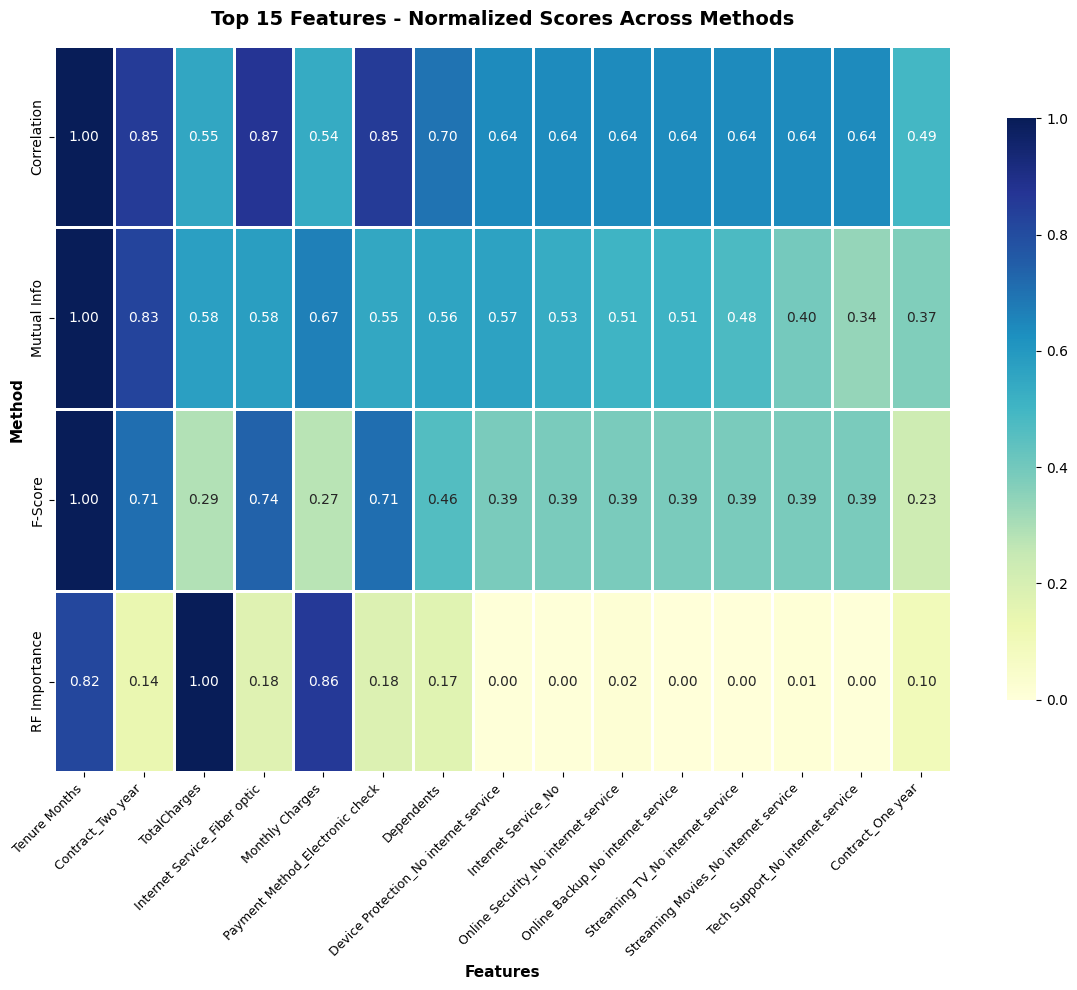

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using your comparison_df from before
top_15 = comparison_df.head(15)

# Create a heatmap showing all methods side by side
fig, ax = plt.subplots(figsize=(12, 10))

# Prepare data for heatmap (normalized scores)
heatmap_data = top_15[['Correlation_Norm', 'Mutual_Info_Norm',
                        'F_Score_Norm', 'RF_Importance_Norm']].T

# Rename for better labels
heatmap_data.columns = top_15['Feature']
heatmap_data.index = ['Correlation', 'Mutual Info', 'F-Score', 'RF Importance']

# Create heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=1, cbar_kws={"shrink": 0.8}, vmin=0, vmax=1)

plt.title('Top 15 Features - Normalized Scores Across Methods',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Features', fontsize=11, fontweight='bold')
plt.ylabel('Method', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

Features with dark colors are helpful in the predictions:
1. Tenure Months
2. Total Charges
3. Payment Method with check
4. Internet service with Fiber Optic

As you can see, there is a discrepancy among the importance of features using various methods.

In [ ]:
redundant_features = [
    'Device Protection_No internet service',
    'Online Security_No internet service',
    'Online Backup_No internet service',
    'Tech Support_No internet service',
    'Streaming TV_No internet service',
    'Streaming Movies_No internet service'
]

# Create cleaned dataset
df_cleaned = df_final.drop(columns=redundant_features)

print(f"Removed {len(redundant_features)} redundant features")
print(f"Original: {df_final.shape[1]} features")
print(f"Cleaned: {df_cleaned.shape[1]} features")

Removed 6 redundant features
Original: 31 features
Cleaned: 25 features


Let's remove redundant columns which are not that helpful and keep the one's which can help us for our modeling dataframe.

In [ ]:
top_consistent = [
    'Tenure Months',
    'Contract_Two year',
    'Monthly Charges',
    'TotalCharges',
    'Payment Method_Electronic check',
    'Internet Service_Fiber optic',
    'Dependents',
    'Churn Value'  # Target
]

# Feature Set 2: Top 10 by average score
top_10_features = comparison_df.head(10)['Feature'].tolist() + ['Churn Value']

# Feature Set 3: RF-focused (what Random Forest thinks matters)
rf_important = comparison_df.nlargest(10, 'RF_Importance')['Feature'].tolist() + ['Churn Value']

print("Feature Set 1 (Consistent):", len(top_consistent)-1, "features")
print("Feature Set 2 (Top 10 avg):", len(top_10_features)-1, "features")
print("Feature Set 3 (RF-based):", len(rf_important)-1, "features")

Feature Set 1 (Consistent): 7 features
Feature Set 2 (Top 10 avg): 10 features
Feature Set 3 (RF-based): 10 features


# Let's check for Bias

Before heading to modeling, let's see if our data has bias which might cause incorrect predictions or predictions with partiality towards the majority.

BIAS ANALYSIS - CLASS IMBALANCE

Churn Distribution:
No Churn (0): 5174 (73.46%)
Churn (1): 1869 (26.54%)

Imbalance Ratio: 2.77:1
⚠️ WARNING: Significant class imbalance detected!
   This can lead to biased predictions favoring the majority class.


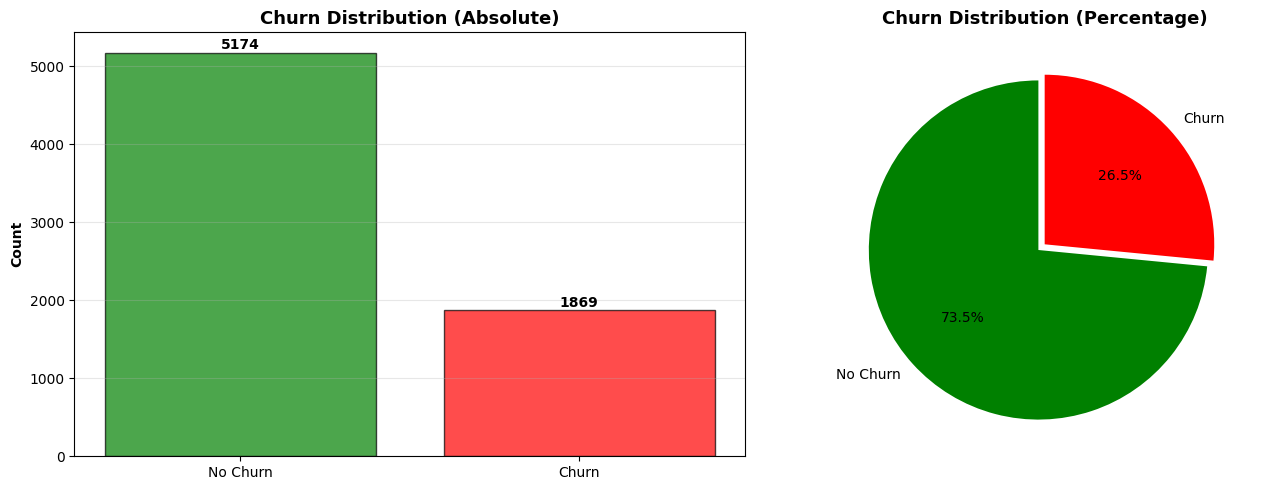

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("="*70)
print("BIAS ANALYSIS - CLASS IMBALANCE")
print("="*70)

# Check target distribution
target_counts = df_cleaned['Churn Value'].value_counts()
target_pct = df_cleaned['Churn Value'].value_counts(normalize=True) * 100

print("\nChurn Distribution:")
print(f"No Churn (0): {target_counts[0]} ({target_pct[0]:.2f}%)")
print(f"Churn (1): {target_counts[1]} ({target_pct[1]:.2f}%)")

imbalance_ratio = target_counts[0] / target_counts[1]
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print("⚠️ WARNING: Significant class imbalance detected!")
    print("   This can lead to biased predictions favoring the majority class.")
else:
    print("✅ Class distribution is relatively balanced")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
axes[0].bar(['No Churn', 'Churn'], target_counts.values,
            color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('Churn Distribution (Absolute)', fontweight='bold', fontsize=13)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Percentage plot
axes[1].pie(target_counts.values, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['green', 'red'],
            startangle=90, explode=(0.05, 0))
axes[1].set_title('Churn Distribution (Percentage)', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

From this we can see that, Most of our data contains records where there is no churn followed by records who have churned. The imbalance ratio is 2.77: 1 which we need to reduce in order to have our predictions without bias.

In [ ]:
print("\n" + "="*70)
print("BIAS ANALYSIS - DEMOGRAPHIC FAIRNESS")
print("="*70)

# Analyze churn rates across demographic groups
demographic_features = ['Gender', 'Senior Citizen', 'Partner', 'Dependents']

demographic_bias = []

for feature in demographic_features:
    if feature in df_cleaned.columns:
        # Calculate churn rate by group
        churn_by_group = df_cleaned.groupby(feature)['Churn Value'].agg([
            ('Total', 'count'),
            ('Churned', 'sum'),
            ('Churn_Rate', 'mean')
        ]).round(4)

        churn_by_group['Churn_Rate_Pct'] = churn_by_group['Churn_Rate'] * 100

        print(f"\n{feature}:")
        print(churn_by_group)

        # Calculate disparity
        max_rate = churn_by_group['Churn_Rate'].max()
        min_rate = churn_by_group['Churn_Rate'].min()
        disparity_ratio = max_rate / min_rate if min_rate > 0 else float('inf')

        demographic_bias.append({
            'Feature': feature,
            'Max_Churn_Rate': max_rate,
            'Min_Churn_Rate': min_rate,
            'Disparity_Ratio': disparity_ratio,
            'Biased': 'Yes' if disparity_ratio > 1.25 else 'No'
        })

        if disparity_ratio > 1.25:
            print(f"⚠️ WARNING: Disparity ratio = {disparity_ratio:.2f} (>1.25 indicates potential bias)")
        else:
            print(f"✅ Acceptable disparity ratio = {disparity_ratio:.2f}")

# Summary table
bias_summary = pd.DataFrame(demographic_bias)
print("\n" + "="*70)
print("DEMOGRAPHIC BIAS SUMMARY")
print("="*70)
print(bias_summary.to_string(index=False))


BIAS ANALYSIS - DEMOGRAPHIC FAIRNESS

Gender:
        Total  Churned  Churn_Rate  Churn_Rate_Pct
Gender                                            
0        3488      939      0.2692           26.92
1        3555      930      0.2616           26.16
✅ Acceptable disparity ratio = 1.03

Senior Citizen:
                Total  Churned  Churn_Rate  Churn_Rate_Pct
Senior Citizen                                            
0                5901     1393      0.2361           23.61
1                1142      476      0.4168           41.68
⚠️ WARNING: Disparity ratio = 1.77 (>1.25 indicates potential bias)

Partner:
         Total  Churned  Churn_Rate  Churn_Rate_Pct
Partner                                            
0         3641     1200      0.3296           32.96
1         3402      669      0.1966           19.66
⚠️ WARNING: Disparity ratio = 1.68 (>1.25 indicates potential bias)

Dependents:
            Total  Churned  Churn_Rate  Churn_Rate_Pct
Dependents                            

It was observed that there could be bias with respect to features such as Partner or Dependents. Dependents generally have a lot more reasons to churn, since there are lot of people involved with one connection.

In [ ]:
print("\n" + "="*70)
print("BIAS ANALYSIS - SAMPLE REPRESENTATION")
print("="*70)

# Check if groups have sufficient representation
for feature in demographic_features:
    if feature in df_cleaned.columns:
        counts = df_cleaned[feature].value_counts()
        total = len(df_cleaned)

        print(f"\n{feature}:")
        for category, count in counts.items():
            pct = (count / total) * 100
            status = "✅" if count > 100 else "⚠️"
            print(f"  {status} Category {category}: {count} ({pct:.1f}%)")

            if count < 100:
                print(f"      WARNING: Small sample size may lead to unreliable predictions")


BIAS ANALYSIS - SAMPLE REPRESENTATION

Gender:
  ✅ Category 1: 3555 (50.5%)
  ✅ Category 0: 3488 (49.5%)

Senior Citizen:
  ✅ Category 0: 5901 (83.8%)
  ✅ Category 1: 1142 (16.2%)

Partner:
  ✅ Category 0: 3641 (51.7%)
  ✅ Category 1: 3402 (48.3%)

Dependents:
  ✅ Category 0: 5416 (76.9%)
  ✅ Category 1: 1627 (23.1%)


This is the sample representation of records across features like Gender; Senior Citizen; Partners and Dependents.



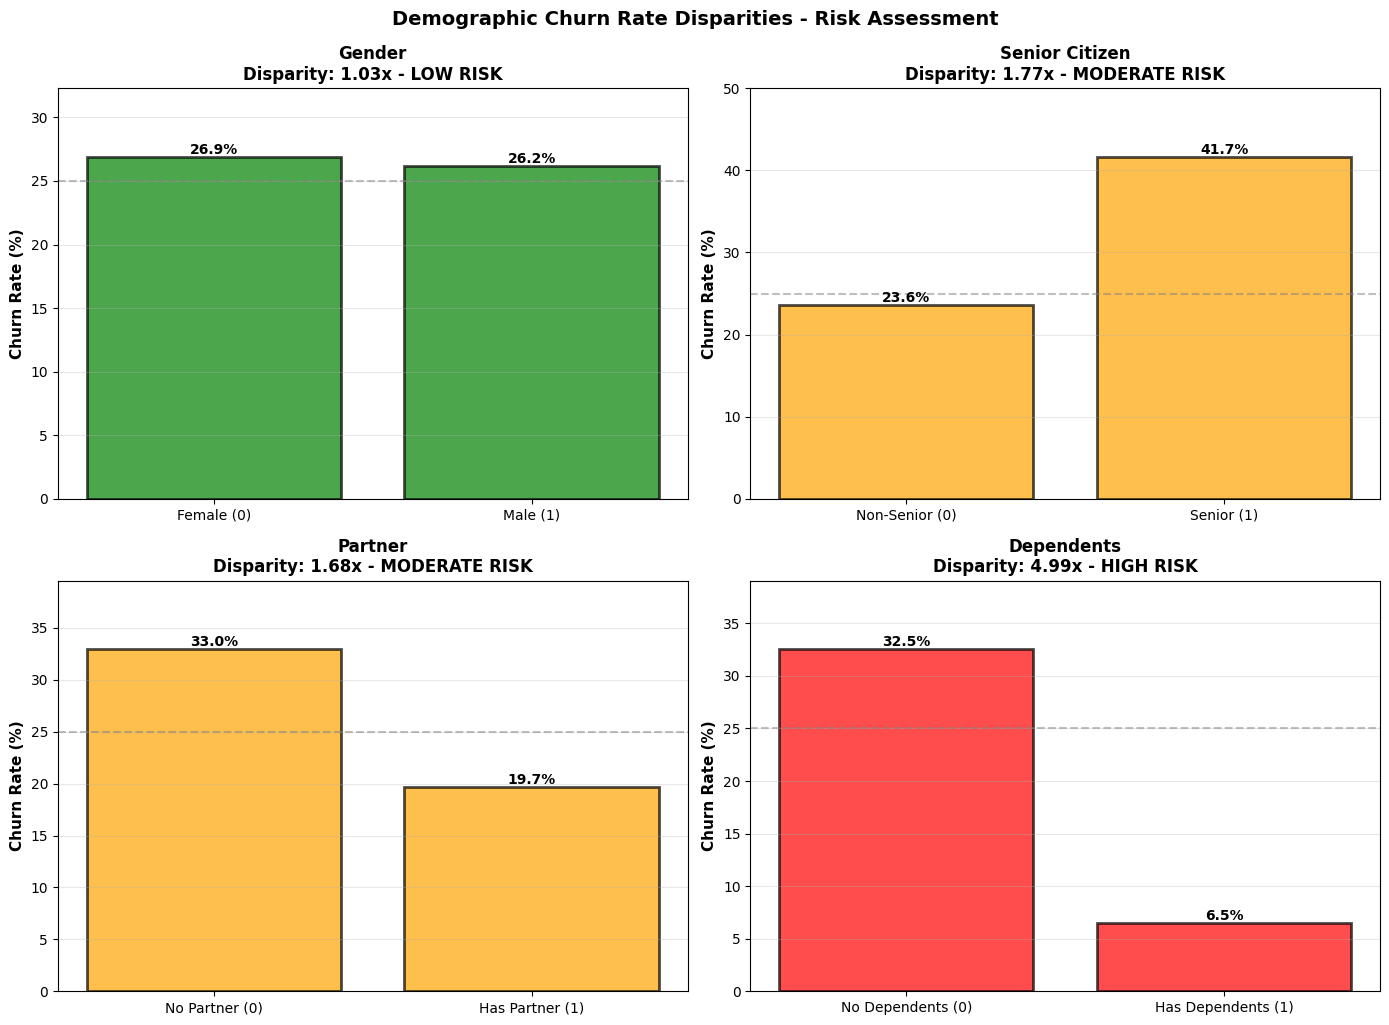

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the bias more clearly
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

bias_data = [
    ('Gender', [26.92, 26.16], ['Female (0)', 'Male (1)'], 1.03),
    ('Senior Citizen', [23.61, 41.68], ['Non-Senior (0)', 'Senior (1)'], 1.77),
    ('Partner', [32.96, 19.66], ['No Partner (0)', 'Has Partner (1)'], 1.68),
    ('Dependents', [32.55, 6.52], ['No Dependents (0)', 'Has Dependents (1)'], 4.99)
]

for idx, (feature, rates, labels, ratio) in enumerate(bias_data):
    ax = axes[idx // 2, idx % 2]

    # Color code by severity
    if ratio < 1.25:
        colors = ['green', 'green']
        severity = 'LOW RISK'
    elif ratio < 2.0:
        colors = ['orange', 'orange']
        severity = 'MODERATE RISK'
    else:
        colors = ['red', 'red']
        severity = 'HIGH RISK'

    bars = ax.bar(labels, rates, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('Churn Rate (%)', fontweight='bold', fontsize=11)
    ax.set_title(f'{feature}\nDisparity: {ratio:.2f}x - {severity}',
                fontweight='bold', fontsize=12)
    ax.set_ylim(0, max(rates) * 1.2)
    ax.grid(axis='y', alpha=0.3)

    # Add percentage labels on bars
    for bar, rate in zip(bars, rates):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{rate:.1f}%', ha='center', va='bottom',
               fontweight='bold', fontsize=10)

    # Add disparity threshold line
    ax.axhline(y=25, color='gray', linestyle='--', alpha=0.5, label='Overall avg')

plt.tight_layout()
plt.suptitle('Demographic Churn Rate Disparities - Risk Assessment',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

Based on the graph, we can see that when there is a huge imbalance it might result in biased predictions strengthening our reasoning or need to balance the dataset, to have proper predictions.

**Let's One hot encode**

For features like Partners and Dependents to reduce the imbalance, I am planning to club them into one feature called "Family Status" and will one-hot encode this multi-value feature.

Here's the idea:
* If no partner or no dependent: Value 0
* If record contains only dependents: Value 1
* If records contains only partner: Value 2
* If records contains both a dependent and a partner: Value 3

In [ ]:
df_cleaned['Family_Status'] = np.where(
    (df_cleaned['Partner'] == 1) & (df_cleaned['Dependents'] == 1), 3,
    np.where(df_cleaned['Partner'] == 1, 2,
    np.where(df_cleaned['Dependents'] == 1, 1, 0))
)

print("Composite Feature Encoding:")
print("  0 = Neither (Highest churn risk)")
print("  1 = Dependents Only")
print("  2 = Partner Only")
print("  3 = Both (Lowest churn risk)")

print("\nDistribution:")
print(df_cleaned['Family_Status'].value_counts().sort_index())

Composite Feature Encoding:
  0 = Neither (Highest churn risk)
  1 = Dependents Only
  2 = Partner Only
  3 = Both (Lowest churn risk)

Distribution:
Family_Status
0    3339
1     302
2    2077
3    1325
Name: count, dtype: int64


- Remove separate Partner and Dependents features
- Replace with single "Family_Status_Encoded" feature (0-3)
- Captures the combined effect explicitly

BENEFITS:
✅ Addresses correlation directly
✅ Captures interaction explicitly
✅ Easier to explain: "Family stability score"
✅ Reduces feature redundancy
✅ More interpretable for business

In [ ]:
df_cleaned.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Churn Value,TotalCharges,...,Device Protection_Yes,Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Family_Status
0,1,0,0,0,2,1,1,53.85,1,108.15,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,1,2,1,1,70.70,1,151.65,...,0,0,0,0,0,0,0,1,0,1
2,0,0,0,1,8,1,1,99.65,1,820.50,...,1,0,1,1,0,0,0,1,0,1
3,0,0,1,1,28,1,1,104.80,1,3046.05,...,1,1,1,1,0,0,0,1,0,3
4,1,0,0,1,49,1,1,103.70,1,5036.30,...,1,0,1,1,0,0,0,0,0,1


In [ ]:
# Remvoing redundant columns
df_cleaned = df_cleaned.drop(columns=['Partner', 'Dependents'])

Dropped Partner and Dependents columns as we have Family Status feature.

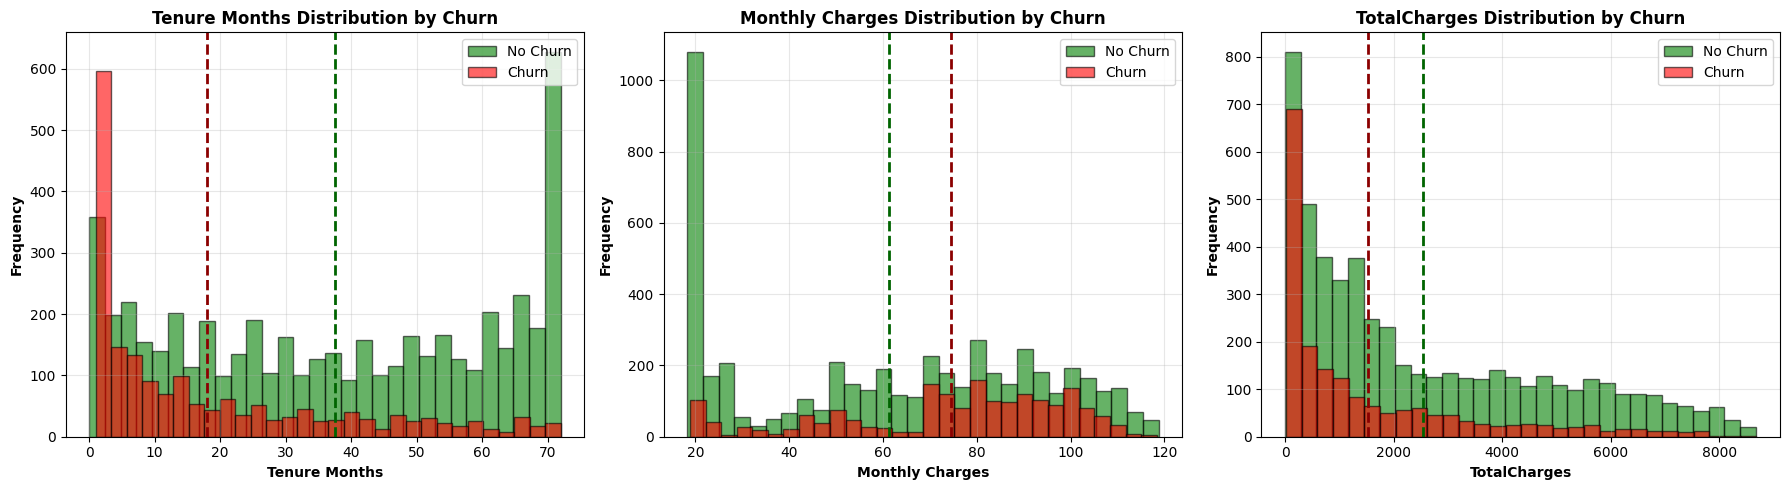


Kolmogorov-Smirnov Test (Distribution Similarity):
(p < 0.05 indicates significantly different distributions)
  Tenure Months: p-value = 0.0000 - Significantly Different ⚠️
  Monthly Charges: p-value = 0.0000 - Significantly Different ⚠️
  TotalCharges: p-value = 0.0000 - Significantly Different ⚠️


In [ ]:
numerical_features = ['Tenure Months', 'Monthly Charges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(numerical_features):
    if feature in df_cleaned.columns:
        # Distribution by churn status
        no_churn = df_cleaned[df_cleaned['Churn Value'] == 0][feature]
        churn = df_cleaned[df_cleaned['Churn Value'] == 1][feature]

        axes[idx].hist(no_churn, bins=30, alpha=0.6, label='No Churn',
                      color='green', edgecolor='black')
        axes[idx].hist(churn, bins=30, alpha=0.6, label='Churn',
                      color='red', edgecolor='black')

        axes[idx].set_xlabel(feature, fontweight='bold')
        axes[idx].set_ylabel('Frequency', fontweight='bold')
        axes[idx].set_title(f'{feature} Distribution by Churn', fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)

        # Add mean lines
        axes[idx].axvline(no_churn.mean(), color='darkgreen',
                         linestyle='--', linewidth=2, label=f'Mean No Churn: {no_churn.mean():.1f}')
        axes[idx].axvline(churn.mean(), color='darkred',
                         linestyle='--', linewidth=2, label=f'Mean Churn: {churn.mean():.1f}')

plt.tight_layout()
plt.show()

# Statistical test for distribution differences
from scipy.stats import ks_2samp

print("\nKolmogorov-Smirnov Test (Distribution Similarity):")
print("(p < 0.05 indicates significantly different distributions)")
for feature in numerical_features:
    if feature in df_cleaned.columns:
        no_churn = df_cleaned[df_cleaned['Churn Value'] == 0][feature]
        churn = df_cleaned[df_cleaned['Churn Value'] == 1][feature]

        statistic, p_value = ks_2samp(no_churn, churn)
        significance = "Significantly Different ⚠️" if p_value < 0.05 else "Similar ✅"
        print(f"  {feature}: p-value = {p_value:.4f} - {significance}")

It's been observed that Total Charges and Tenure Months are helpful for us to predict the churn. Since, TotalCharges is a derived column i.e. a product of tenure and monthly charges TotalCharges can be dropped.

But let's check for thier relationship, if there's a high correlation it's better to drop it.


Correlation Matrix:
                 Tenure Months  Monthly Charges  TotalCharges
Tenure Months         1.000000         0.247900      0.826178
Monthly Charges       0.247900         1.000000      0.651174
TotalCharges          0.826178         0.651174      1.000000

⚠️ High Correlation Warnings:

🚨 SEVERE: Tenure Months ↔ TotalCharges: 0.826
   These features are highly redundant!
   RECOMMENDATION: Remove one of them

⚠️ MODERATE: Monthly Charges ↔ TotalCharges: 0.651
   Consider removing one if model overfits


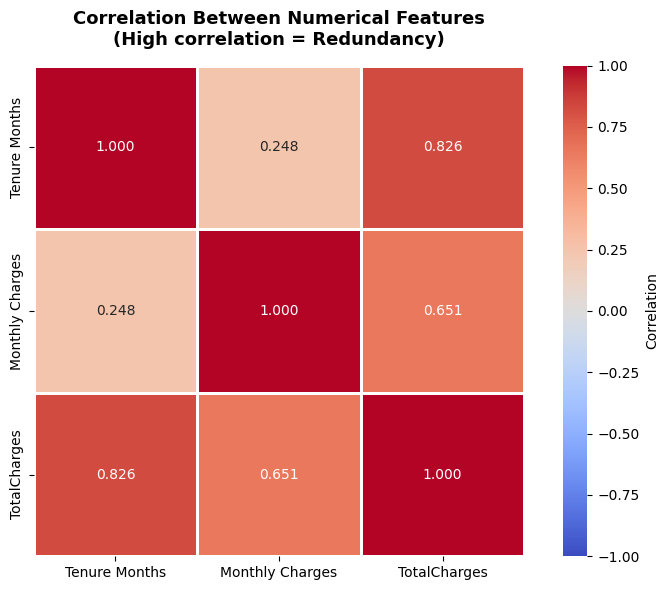


Variance Inflation Factor (VIF):
           Feature       VIF
0    Tenure Months  6.332328
1  Monthly Charges  3.355660
2     TotalCharges  8.075070

Interpretation:
  VIF < 5: ✅ No multicollinearity
  VIF 5-10: ⚠️ Moderate multicollinearity
  VIF > 10: 🚨 Severe multicollinearity - remove feature!


In [ ]:
features_to_test = ['Tenure Months', 'Monthly Charges', 'TotalCharges']

correlation_matrix = df_cleaned[features_to_test].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Highlight high correlations
print("\n⚠️ High Correlation Warnings:")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        feat1 = correlation_matrix.columns[i]
        feat2 = correlation_matrix.columns[j]

        if abs(corr_val) > 0.8:
            print(f"\n🚨 SEVERE: {feat1} ↔ {feat2}: {corr_val:.3f}")
            print(f"   These features are highly redundant!")
            print(f"   RECOMMENDATION: Remove one of them")
        elif abs(corr_val) > 0.5:
            print(f"\n⚠️ MODERATE: {feat1} ↔ {feat2}: {corr_val:.3f}")
            print(f"   Consider removing one if model overfits")

# Visualize correlation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=2,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Between Numerical Features\n(High correlation = Redundancy)',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# Calculate VIF to check multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_numeric = df_cleaned[features_to_test]
vif_data = pd.DataFrame()
vif_data["Feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i)
                   for i in range(X_numeric.shape[1])]

print("\nVariance Inflation Factor (VIF):")
print(vif_data)
print("\nInterpretation:")
print("  VIF < 5: ✅ No multicollinearity")
print("  VIF 5-10: ⚠️ Moderate multicollinearity")
print("  VIF > 10: 🚨 Severe multicollinearity - remove feature!")

In [ ]:
# Let's drop total charges as it is a derived column and unnecassarily cause bias
df_cleaned = df_cleaned.drop(columns=['TotalCharges'])
df_cleaned

,Gender,Senior Citizen,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Churn Value,Multiple Lines_No phone service,Multiple Lines_Yes,Internet Service_Fiber optic,...,Device Protection_Yes,Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Family_Status
0,1,0,2,1,1,53.85,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,2,1,1,70.70,1,0,0,1,...,0,0,0,0,0,0,0,1,0,1
2,0,0,8,1,1,99.65,1,0,1,1,...,1,0,1,1,0,0,0,1,0,1
3,0,0,28,1,1,104.80,1,0,1,1,...,1,1,1,1,0,0,0,1,0,3
4,1,0,49,1,1,103.70,1,0,1,1,...,1,0,1,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,72,1,1,21.15,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7039,1,0,24,1,1,84.80,0,0,1,0,...,1,1,1,1,1,0,0,0,1,3
7040,0,0,72,1,1,103.20,0,0,1,1,...,1,0,1,1,1,0,1,0,0,3
7041,0,0,11,0,1,29.60,0,1,0,0,...,0,0,0,0,0,0,0,1,0,3


# Fitting the Model

In [ ]:
tele_df = df_cleaned.copy()

Now with the dataframe cleaned and cleared from redundant columns it is time to fit the model. However, since our data is imbalanced, we will perform SMOTE analysis on Training Data so that the sample size will be balanced. However, the Testing Data won't be performed with SMOTE analysis so as to not influence its predictions.

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd

X = tele_df.drop('Churn Value', axis=1)
y = tele_df['Churn Value']

print("\n STEP 1: Original Data")
print(f"Total samples: {len(X)}")
print(f"Features: {X.shape[1]}")
print(f"Class distribution:")
print(y.value_counts())
print(f"Imbalance ratio: {(y==0).sum() / (y==1).sum():.2f}:1")

# Splitting dataset into Train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 80% train, 20% test
    random_state=42,
    stratify=y               # Keep same ratio in train/test
)

print("\n STEP 2: After Train/Test Split")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

print(f"\nTraining distribution:")
print(pd.Series(y_train).value_counts())
print(f"Training imbalance: {(y_train==0).sum() / (y_train==1).sum():.2f}:1")

print(f"\nTest distribution (KEPT ORIGINAL IMBALANCE):")
print(pd.Series(y_test).value_counts())
print(f"Test imbalance: {(y_test==0).sum() / (y_test==1).sum():.2f}:1")

# Apply SMOTE only to the training data
print("\n STEP 3: Applying SMOTE to TRAINING DATA ONLY")
print(" CRITICAL: Test data remains UNTOUCHED!")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nTraining set after SMOTE:")
print(f"Shape: {X_train_balanced.shape}")
print(f"Distribution:")
print(pd.Series(y_train_balanced).value_counts())
print(f"Balance ratio: {(y_train_balanced==0).sum() / (y_train_balanced==1).sum():.2f}:1")

# How many synthetic samples were created?
original_minority = (y_train == 1).sum()
new_minority = (y_train_balanced == 1).sum()
synthetic_created = new_minority - original_minority

print(f"\n Created {synthetic_created} synthetic churn samples")
print(f" Training data is now balanced!")

# STEP 4: Train Model
# ============================================================
print("\n STEP 4: Training Model")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',    # Extra protection
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_balanced, y_train_balanced)
print("✅ Model trained successfully!")



 STEP 1: Original Data
Total samples: 7043
Features: 22
Class distribution:
Churn Value
0    5174
1    1869
Name: count, dtype: int64
Imbalance ratio: 2.77:1

 STEP 2: After Train/Test Split
Training set: (5634, 22)
Test set: (1409, 22)

Training distribution:
Churn Value
0    4139
1    1495
Name: count, dtype: int64
Training imbalance: 2.77:1

Test distribution (KEPT ORIGINAL IMBALANCE):
Churn Value
0    1035
1     374
Name: count, dtype: int64
Test imbalance: 2.77:1

 STEP 3: Applying SMOTE to TRAINING DATA ONLY
 CRITICAL: Test data remains UNTOUCHED!

Training set after SMOTE:
Shape: (8278, 22)
Distribution:
Churn Value
0    4139
1    4139
Name: count, dtype: int64
Balance ratio: 1.00:1

 Created 2644 synthetic churn samples
 Training data is now balanced!

 STEP 4: Training Model
✅ Model trained successfully!


# Model Evaluation

In [ ]:
# Evaluating the model

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Metrics
print("\n" + "="*70)
print("MODEL PERFORMANCE (On Original Imbalanced Test Data)")
print("="*70)

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                           target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"                Predicted")
print(f"                No Churn    Churn")
print(f"Actual No Churn    {tn:4d}      {fp:4d}")
print(f"Actual Churn       {fn:4d}      {tp:4d}")

# Key Metrics
print(f"\n📈 Key Metrics:")
print(f"Total test samples: {len(y_test)}")
print(f"Actual churns in test: {(y_test==1).sum()}")
print(f"Churns caught by model: {tp}")
print(f"Churns missed by model: {fn}")
print(f"Churn Recall: {tp/(tp+fn)*100:.1f}%")
print(f"Churn Precision: {tp/(tp+fp)*100:.1f}%")



MODEL PERFORMANCE (On Original Imbalanced Test Data)

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
       Churn       0.55      0.73      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409


Confusion Matrix:
                Predicted
                No Churn    Churn
Actual No Churn     815       220
Actual Churn        101       273

📈 Key Metrics:
Total test samples: 1409
Actual churns in test: 374
Churns caught by model: 273
Churns missed by model: 101
Churn Recall: 73.0%
Churn Precision: 55.4%


Let's see the confusion matrix:
Our model predicts 815 records correctly as churned. (True Positive) and 220 records as not churned, even though they've churned (False Negative/ Type-2 error).

Our model predicts 101 records as churned, even though they aren't (False Positive/ Type-1 error) and 273 records as not churned correctly (True Negative)

The total test samples were 1409.

The recall is 73%, which means the model can catch 3 out of 4 churns!
Precison is 55%, 220 records was false alarm but given the scale, it can be accepted. Model prioritizes catching churns over perfect accuracy!

In [ ]:
# AUC
auc = roc_auc_score(y_test, y_proba)
print(f"\n🎯 AUC-ROC Score: {auc:.4f}")

if auc > 0.85:
    print("✅ Excellent performance!")
elif auc > 0.75:
    print("✅ Good performance!")
elif auc > 0.65:
    print("⚠️ Acceptable performance")
else:
    print("❌ Needs improvement")


🎯 AUC-ROC Score: 0.8477
✅ Good performance!


The AUC-ROC score of 84% tells us that the model gives out a good performance but certainly there is room for betterment.

The score is used for measuring performance of classification models. ROC curve is a probability curve that plots True Positive Rate against False Positive Rate.

# Explainable AI (XAI)

Let's do SHAP analysis to explain the black-box working of our model.

XAI helps us in:

Adding BUSINESS VALUE:


---



✅ Transparent AI - stakeholders understand WHY predictions made

✅ Actionable insights - know WHICH features to target

✅ Customer-specific strategies - personalized retention

✅ Fair and ethical - can audit for bias

✅ Regulatory compliance - meets explainability requirements


✅ Global feature importance (which features matter most)

✅ Feature impact distribution (how values affect predictions)

✅ Individual customer explanations (why specific predictions)

✅ Force plots (visual breakdown of contributions)

✅ Dependence plots (feature value relationships)

✅ Decision plots (prediction paths for multiple customers)





In [ ]:
!pip install shap

COMPLETE FIX - HANDLING 3D SHAP VALUES

📊 Step 1: Preparing data...
Sample size: 100
Features: 22

📊 Step 2: Creating SHAP explainer...

🔍 Analyzing SHAP values structure...
Type: <class 'numpy.ndarray'>
Shape: (100, 22, 2)
✅ 3D array detected: (100, 22, 2)
   (samples, features, classes) = (100, 22, 2)
✅ Extracted Churn SHAP values: (100, 22)

✅ Final shape: (100, 22)
   Expected: (100, 22)
✅ Shape verification passed!

📊 VISUALIZATION 1: GLOBAL FEATURE IMPORTANCE


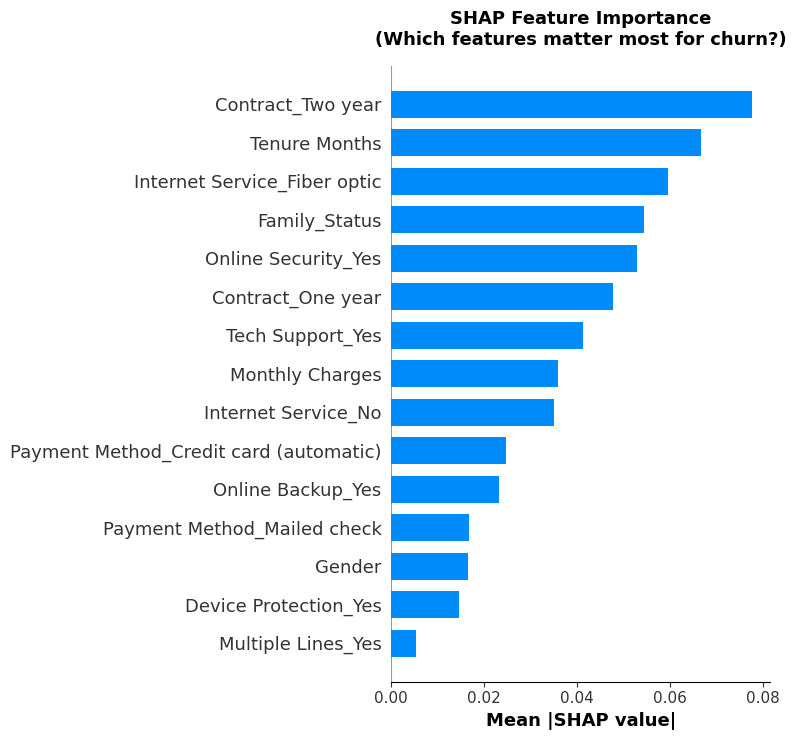


💡 Top features have biggest impact on predictions

📊 VISUALIZATION 2: FEATURE IMPACT DETAILS


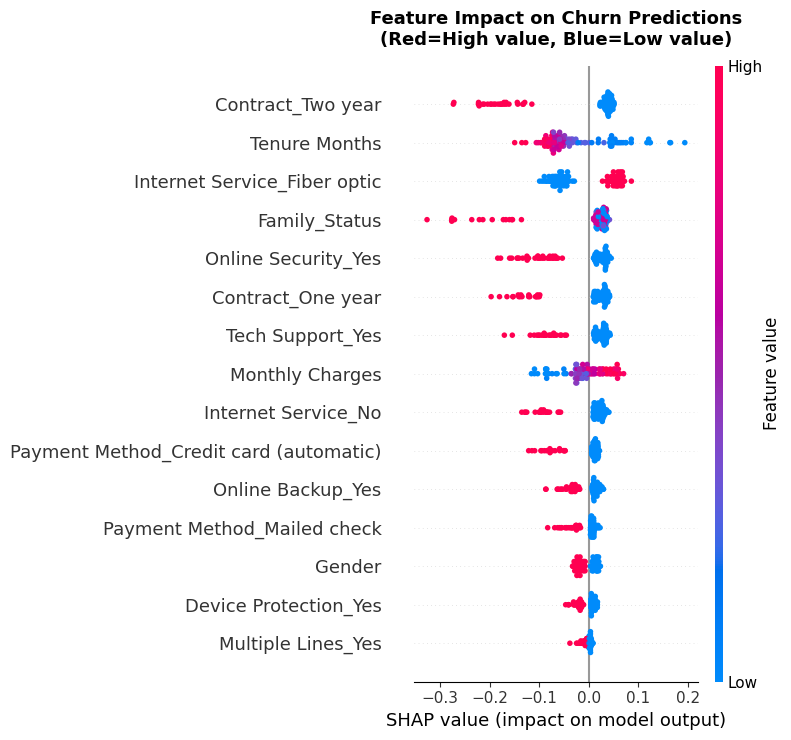


💡 Right side = Increases churn risk
   Left side = Decreases churn risk

📊 VISUALIZATION 3: INDIVIDUAL CUSTOMER EXPLANATION

Customer #1:
  Actual: Stayed
  Predicted: Churn
  Churn Probability: 69.6%


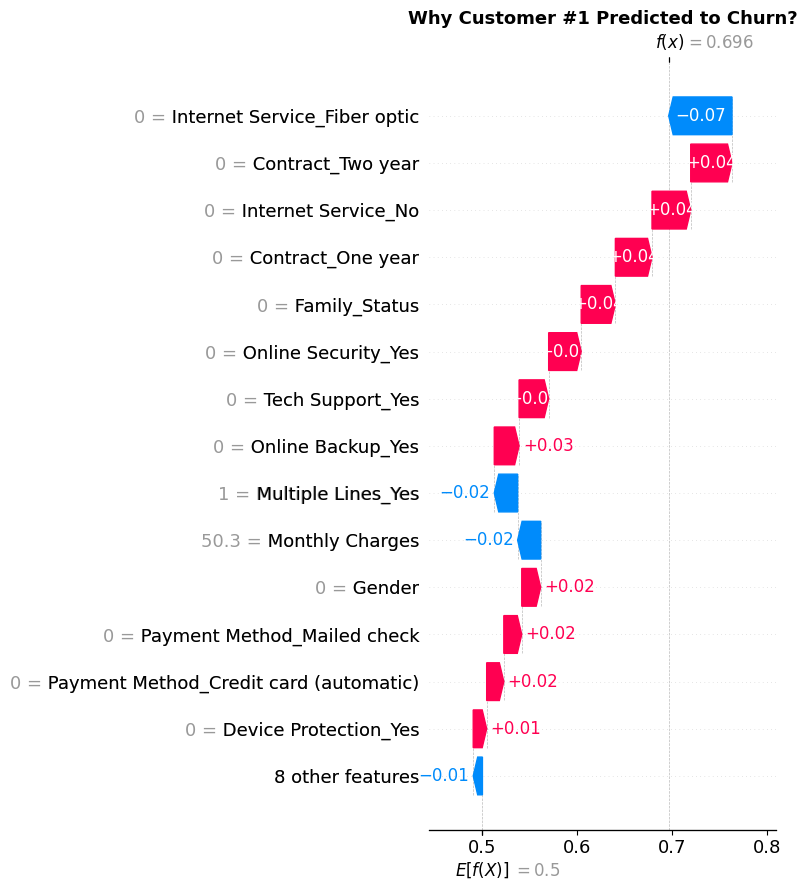


💡 Red = Pushes toward churn
   Blue = Pushes toward no churn

📋 Top 10 Contributing Features:
                     Feature  Value  SHAP_Impact
Internet Service_Fiber optic    0.0    -0.066630
           Contract_Two year    0.0     0.043452
         Internet Service_No    0.0     0.040758
           Contract_One year    0.0     0.038566
               Family_Status    0.0     0.035966
         Online Security_Yes    0.0     0.034255
            Tech Support_Yes    0.0     0.031134
           Online Backup_Yes    0.0     0.026132
          Multiple Lines_Yes    1.0    -0.024579
             Monthly Charges   50.3    -0.024254

📊 VISUALIZATION 4: FORCE PLOT


<Figure size 1400x300 with 0 Axes>

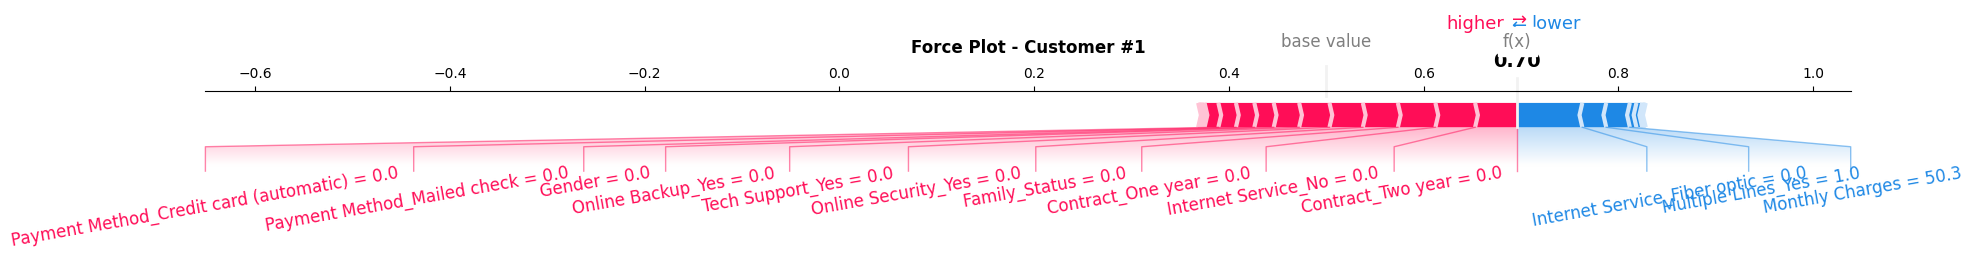


📊 VISUALIZATION 5: TOP 3 FEATURE DEPENDENCE PLOTS
Top 3 features: ['Contract_Two year', 'Tenure Months', 'Internet Service_Fiber optic']


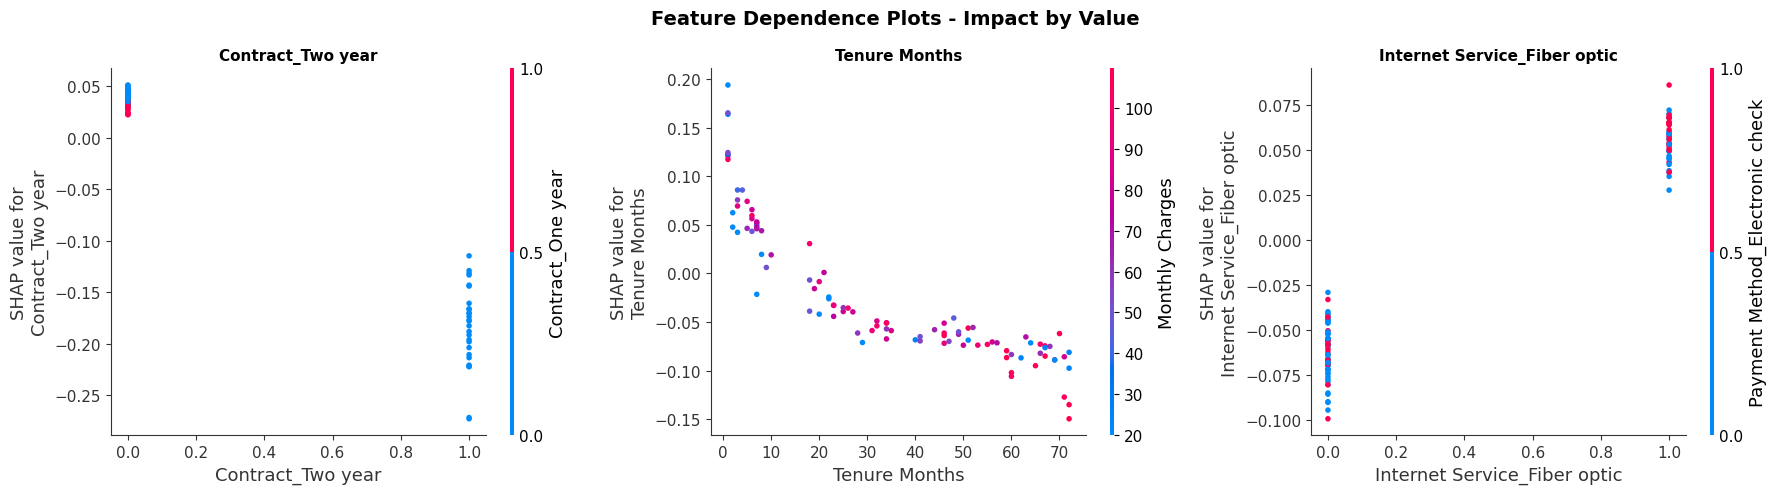


📊 VISUALIZATION 6: DECISION PLOT (20 CUSTOMERS)


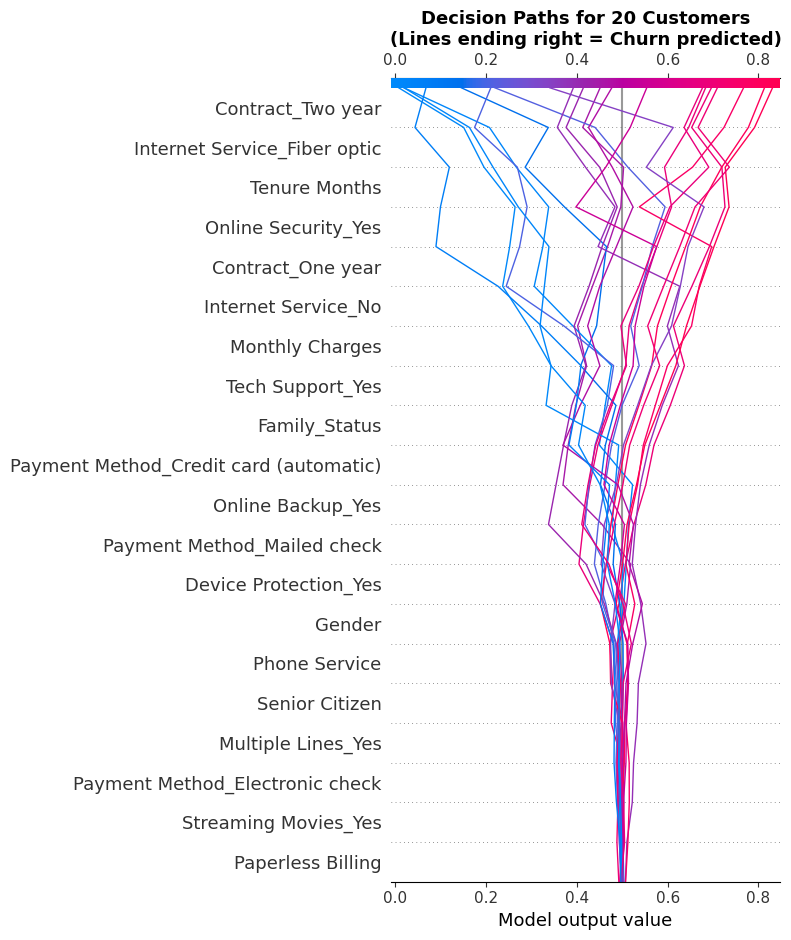


💡 Each line shows how features combine to make a prediction

📊 FEATURE IMPORTANCE SUMMARY

🏆 Top 15 Features by Importance:
                               Feature  Mean_Abs_SHAP  Mean_SHAP
                     Contract_Two year       0.077670  -0.021486
                         Tenure Months       0.066568  -0.022767
          Internet Service_Fiber optic       0.059430  -0.010227
                         Family_Status       0.054327  -0.010366
                   Online Security_Yes       0.052843  -0.016645
                     Contract_One year       0.047630  -0.004844
                      Tech Support_Yes       0.041153  -0.002459
                       Monthly Charges       0.035856  -0.008263
                   Internet Service_No       0.034960  -0.000919
Payment Method_Credit card (automatic)       0.024735  -0.003293
                     Online Backup_Yes       0.023191  -0.002440
           Payment Method_Mailed check       0.016722  -0.004224
                              

In [ ]:
print("="*70)
print("COMPLETE FIX - HANDLING 3D SHAP VALUES")
print("="*70)

import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# STEP 1: Prepare Data
# ============================================================
print("\n📊 Step 1: Preparing data...")

sample_size = 100
X_test_sample = X_test.sample(n=min(sample_size, len(X_test)), random_state=42)
y_test_sample = y_test[X_test_sample.index]

print(f"Sample size: {len(X_test_sample)}")
print(f"Features: {X_test_sample.shape[1]}")

# ============================================================
# STEP 2: Create SHAP Explainer & Calculate Values
# ============================================================
print("\n📊 Step 2: Creating SHAP explainer...")

explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_test_sample)

# ============================================================
# CRITICAL: Handle 3D SHAP values correctly
# ============================================================
print("\n🔍 Analyzing SHAP values structure...")
print(f"Type: {type(shap_values_raw)}")
print(f"Shape: {shap_values_raw.shape if hasattr(shap_values_raw, 'shape') else 'List'}")

# For newer SHAP versions with 3D output: (samples, features, classes)
if isinstance(shap_values_raw, np.ndarray) and len(shap_values_raw.shape) == 3:
    print(f"✅ 3D array detected: {shap_values_raw.shape}")
    print(f"   (samples, features, classes) = ({shap_values_raw.shape[0]}, {shap_values_raw.shape[1]}, {shap_values_raw.shape[2]})")

    # Extract CHURN class (class 1, last dimension)
    shap_values_churn = shap_values_raw[:, :, 1]
    expected_value = explainer.expected_value[1]

    print(f"✅ Extracted Churn SHAP values: {shap_values_churn.shape}")

# For older SHAP versions with list output
elif isinstance(shap_values_raw, list):
    print(f"✅ List detected (binary classification)")
    shap_values_churn = shap_values_raw[1]
    expected_value = explainer.expected_value[1]
    print(f"✅ Using Churn class: {shap_values_churn.shape}")

# Single output
else:
    print(f"✅ Single output: {shap_values_raw.shape}")
    shap_values_churn = shap_values_raw
    expected_value = explainer.expected_value

print(f"\n✅ Final shape: {shap_values_churn.shape}")
print(f"   Expected: ({len(X_test_sample)}, {X_test_sample.shape[1]})")

# Verify shape is 2D
assert len(shap_values_churn.shape) == 2, f"Shape should be 2D, got {shap_values_churn.shape}!"
assert shap_values_churn.shape == (len(X_test_sample), X_test_sample.shape[1]), "Shape mismatch!"

print("✅ Shape verification passed!")

# ============================================================
# VISUALIZATION 1: Global Feature Importance (Bar)
# ============================================================
print("\n" + "="*70)
print("📊 VISUALIZATION 1: GLOBAL FEATURE IMPORTANCE")
print("="*70)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_churn,
    X_test_sample,
    plot_type="bar",
    show=False,
    max_display=15
)
plt.title('SHAP Feature Importance\n(Which features matter most for churn?)',
         fontweight='bold', fontsize=13, pad=15)
plt.xlabel('Mean |SHAP value|', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Top features have biggest impact on predictions")

# ============================================================
# VISUALIZATION 2: Summary Plot (Beeswarm)
# ============================================================
print("\n" + "="*70)
print("📊 VISUALIZATION 2: FEATURE IMPACT DETAILS")
print("="*70)

plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values_churn,
    X_test_sample,
    show=False,
    max_display=15
)
plt.title('Feature Impact on Churn Predictions\n(Red=High value, Blue=Low value)',
         fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print("\n💡 Right side = Increases churn risk")
print("   Left side = Decreases churn risk")

# ============================================================
# VISUALIZATION 3: Individual Explanation (Waterfall)
# ============================================================
print("\n" + "="*70)
print("📊 VISUALIZATION 3: INDIVIDUAL CUSTOMER EXPLANATION")
print("="*70)

# Find a customer predicted to churn
y_pred_sample = model.predict(X_test_sample)
y_proba_sample = model.predict_proba(X_test_sample)
churn_indices = np.where(y_pred_sample == 1)[0]

if len(churn_indices) > 0:
    customer_idx = churn_indices[0]
else:
    customer_idx = 0
    print("⚠️ No churns predicted, using first customer")

print(f"\nCustomer #{customer_idx}:")
print(f"  Actual: {'Churned' if y_test_sample.iloc[customer_idx] == 1 else 'Stayed'}")
print(f"  Predicted: {'Churn' if y_pred_sample[customer_idx] == 1 else 'No Churn'}")
print(f"  Churn Probability: {y_proba_sample[customer_idx][1]:.1%}")

# Create waterfall plot - CORRECT way
plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_churn[customer_idx],  # Now 1D: (22,)
        base_values=expected_value,
        data=X_test_sample.iloc[customer_idx].values,
        feature_names=X_test_sample.columns.tolist()
    ),
    show=False,
    max_display=15
)

plt.title(f'Why Customer #{customer_idx} Predicted to {"Churn" if y_pred_sample[customer_idx] == 1 else "Stay"}?',
         fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\n💡 Red = Pushes toward churn")
print("   Blue = Pushes toward no churn")

# Show feature details
print(f"\n📋 Top 10 Contributing Features:")
feature_contrib = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Value': X_test_sample.iloc[customer_idx].values,
    'SHAP_Impact': shap_values_churn[customer_idx]
}).sort_values('SHAP_Impact', key=abs, ascending=False)

print(feature_contrib.head(10).to_string(index=False))

# ============================================================
# VISUALIZATION 4: Force Plot
# ============================================================
print("\n" + "="*70)
print("📊 VISUALIZATION 4: FORCE PLOT")
print("="*70)

# Initialize for Colab
shap.initjs()

plt.figure(figsize=(14, 3))
shap.force_plot(
    expected_value,
    shap_values_churn[customer_idx],
    X_test_sample.iloc[customer_idx],
    matplotlib=True,
    show=False,
    text_rotation=10
)
plt.title(f'Force Plot - Customer #{customer_idx}', fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 5: Dependence Plots
# ============================================================
print("\n" + "="*70)
print("📊 VISUALIZATION 5: TOP 3 FEATURE DEPENDENCE PLOTS")
print("="*70)

# Get top 3 features
feature_importance = np.abs(shap_values_churn).mean(axis=0)
top_3_idx = np.argsort(feature_importance)[-3:][::-1]
top_3_features = X_test_sample.columns[top_3_idx].tolist()

print(f"Top 3 features: {top_3_features}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(top_3_features):
    shap.dependence_plot(
        feature,
        shap_values_churn,
        X_test_sample,
        ax=axes[idx],
        show=False
    )
    axes[idx].set_title(f'{feature}', fontweight='bold', fontsize=11)

plt.suptitle('Feature Dependence Plots - Impact by Value',
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 6: Multiple Customer Decisions
# ============================================================
print("\n" + "="*70)
print("📊 VISUALIZATION 6: DECISION PLOT (20 CUSTOMERS)")
print("="*70)

num_customers = min(20, len(X_test_sample))

plt.figure(figsize=(12, 8))
shap.decision_plot(
    expected_value,
    shap_values_churn[:num_customers],
    X_test_sample.iloc[:num_customers],
    show=False
)
plt.title(f'Decision Paths for {num_customers} Customers\n(Lines ending right = Churn predicted)',
         fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\n💡 Each line shows how features combine to make a prediction")

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*70)
print("📊 FEATURE IMPORTANCE SUMMARY")
print("="*70)

feature_importance_df = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_churn).mean(axis=0),
    'Mean_SHAP': shap_values_churn.mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("\n🏆 Top 15 Features by Importance:")
print(feature_importance_df.head(15).to_string(index=False))

# Business insights
print("\n💼 KEY BUSINESS INSIGHTS:")
print("="*70)

top_feature = feature_importance_df.iloc[0]
print(f"\n1. Most Important Feature: {top_feature['Feature']}")
print(f"   Average Impact: {top_feature['Mean_Abs_SHAP']:.4f}")
print(f"   Direction: {'→ Higher values increase churn' if top_feature['Mean_SHAP'] > 0 else '→ Lower values increase churn'}")

top_5 = feature_importance_df.head(5)
print(f"\n2. Top 5 Drivers of Churn:")
for idx, row in top_5.iterrows():
    direction = "↑" if row['Mean_SHAP'] > 0 else "↓"
    print(f"   {direction} {row['Feature']}: {row['Mean_Abs_SHAP']:.4f}")

print("\n" + "="*70)
print("✅ SHAP ANALYSIS COMPLETE!")
print("="*70)


# Save feature importance
feature_importance_df.to_csv('shap_feature_importance.csv', index=False)
print("💾 Feature importance saved to 'shap_feature_importance.csv'")

# Further Work and References:

This work is by all means not the end, I had to make a few trade-offs, can work around with various models to improve the predictions, etc. As I learn further, I'll make my best effort to teach while learning :)!

References I used:
 https://www.kaggle.com/code/tawfikelmetwally/customer-churn-analysis-plotly-visualization

 https://www.kaggle.com/code/hely333/customer-churn-eda-prediction-f1-score-87

 Tools: Claude!
